# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [1]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [2]:
def download_and_load_stl10():
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )
    base_dir = os.path.dirname(path)
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")
    print(f"Loading data from: {filepath}")
    with open(filepath, 'rb') as f:
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))
        images = np.transpose(images, (0, 3, 2, 1))
    return images


class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")
        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0
            Y[i] = full_img
            patches = []
            for r in range(3):
                for c in range(3):
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start:y_start+self.patch_size,
                                     x_start:x_start+self.patch_size, :]
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin:margin+self.crop_size,
                                  margin:margin+self.crop_size, :]
                    patches.append(patch)
            order = np.random.permutation(9)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]
        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [3]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 177s 0us/step
Loading data from: /root/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [4]:
print(images.shape)

(100000, 96, 96, 3)


In [5]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [6]:
# batch_size=64 for practical training time on GPU
# Prof's default batch_size=8 results in ~8hrs/epoch on full dataset
train_generator = PatchGenerator(train_images, batch_size=64)
val_generator   = PatchGenerator(val_images,   batch_size=64, shuffle=False)
test_generator  = PatchGenerator(test_images,  batch_size=64, shuffle=False)

Let us inspect the dataset.

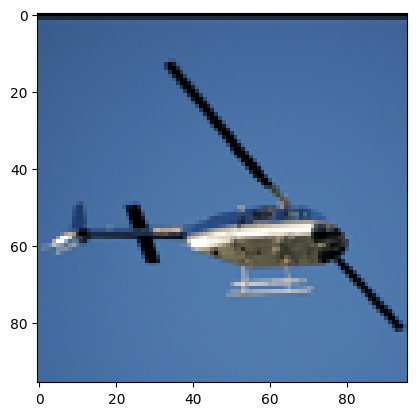

In [38]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [9]:
a,b = test_generator.__getitem__(3)

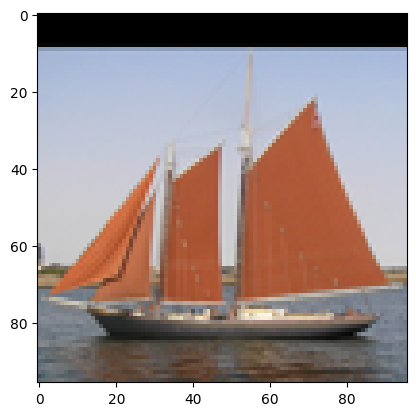

In [10]:
plt.imshow(b[4])

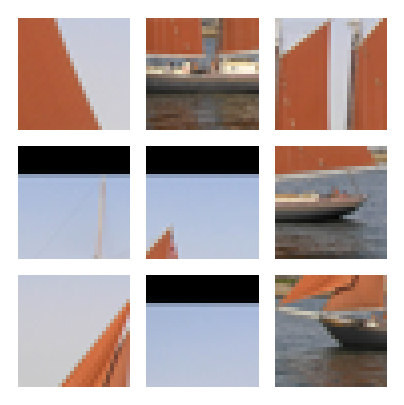

In [11]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [12]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [13]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.1822178, shape=(), dtype=float32)
std: tf.Tensor(0.0014526013, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





## Stage 1 Patch Encoder

Each of the 9 patches is encoded independently by a shared CNN into a
128-dimensional feature vector. Shared weights via TimeDistributed reduce
parameter count while ensuring consistent feature extraction across all patches.
Architecture ideaa based on residual conv-block from Cifar_10_separation demo.

In [14]:
#re-doing just for reference.
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0]
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    mean_patches = tf.repeat(mean_patch[:, None, :, :, :], repeats=9, axis=1)
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

# Compute baseline MAE on test set
mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a, b = test_generator[i]
    pred = mean_patch_image(a)
    mae_values.append(mae_metric(pred, b).numpy())

print("Baseline MAE:", np.mean(mae_values))
print("Baseline std:", np.std(mae_values))

Baseline MAE: 0.1822178
Baseline std: 0.001452601


## Building Blocks

Before defining the model stages, we define three reusable building blocks used throughout the architecture.

`conv_block` is a residual convolutional block taken from prof's Cifar_10_separation demo. It applies two Conv2D layers with BatchNormalization and LeakyReLU, then adds the original input back via a shortcut connection. This residual design helps gradients flow during training and prevents information loss.

`down_block` and `up_block` form the U-Net encoder-decoder pair, taken from prof's Inpainting_satellite_images demo. The down block extracts features and halves spatial dimensions while saving a skip connection. The up block doubles spatial dimensions and concatenates the saved skip to recover fine-grained details lost during downsampling.

In [15]:
EMBED_DIM = 128

# residual conv block (same idea as conv_block in Cifar_10_separation demo)
def conv_block(x, filters, pooling=False):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
    x = layers.Add()([x, shortcut])
    if pooling:
        x = layers.MaxPooling2D()(x)
    return x

# U-net down and up blocks (from Inpainting_satellite_images demo)
def down_block(x, filters):
    skip = layers.Conv2D(filters, 3, padding="same")(x)
    skip = layers.BatchNormalization()(skip)
    skip = layers.LeakyReLU(0.1)(skip)
    skip = layers.Conv2D(filters, 3, padding="same")(skip)
    skip = layers.BatchNormalization()(skip)
    skip = layers.LeakyReLU(0.1)(skip)
    pool = layers.MaxPooling2D()(skip)
    return skip, pool

def up_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    return x

## Stage 1  Patch Encoder

Each of the 9 patches is encoded independently into a 128-dimensional feature vector using a shared CNN. The encoder applies three residual conv blocks that progressively shrink the spatial dimensions from 28×28 down to 7×7, then uses Global Average Pooling to collapse the spatial dimensions into a single vector. A final Dense layer projects this to EMBED_DIM=128.

The same encoder is applied to all 9 patches via TimeDistributed, meaning one set of weights handles all patches. This makes sense since the same visual features appear in any patch regardless of content.

In [16]:
# Stage 1: encode each patch into a feature vector
def build_patch_encoder():
    inp = layers.Input(shape=(28, 28, 3))
    x = conv_block(inp, 32, pooling=True)
    x = conv_block(x, 64, pooling=True)
    x = conv_block(x, 128, pooling=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(EMBED_DIM)(x)
    return keras.Model(inp, x, name="patch_encoder")

patch_encoder = build_patch_encoder()
patch_encoder.summary()

Model: "patch_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      9,248 │ leaky_re_lu[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │        128 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ leaky_re_lu_1[0]… │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │     36,928 │ leaky_re_lu_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │      2,112 │ max_pooling2d[0]

 Total params: 315,872 (1.20 MB)

 Trainable params: 314,976 (1.20 MB)

 Non-trainable params: 896 (3.50 KB)

## Stage 2  Transformer Reasoning

After encoding each patch individually, we need the patches to reason about their relative spatial positions. A Transformer with multi-head self-attention allows all 9 patch features to attend to each other simultaneously, which is the natural choice since the input is a set of unordered tokens — exactly the setup from prof's Vision Transformer slides.

Learnable positional embeddings are added to the 9 features before attention, so the model can learn what each grid slot means spatially. We stack 3 transformer blocks, each consisting of multi-head attention followed by a feed-forward network, both with residual connections and LayerNormalization. This design follows the standard transformer architecture taught in class.

In [17]:
# Stage 2: transformer so the 9 patches can attend to each other
def transformer_block(x, num_heads=4, ff_dim=256, dropout=0.1):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=EMBED_DIM // num_heads)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization()(x + attn)
    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(EMBED_DIM)(ff)
    ff = layers.Dropout(dropout)(ff)
    x = layers.LayerNormalization()(x + ff)
    return x

def build_reasoning_module(num_blocks=3):
    inp = layers.Input(shape=(9, EMBED_DIM))
    positions = tf.range(9)
    pos_emb = layers.Embedding(9, EMBED_DIM)(positions)
    x = inp + pos_emb
    for _ in range(num_blocks):
        x = transformer_block(x)
    return keras.Model(inp, x, name="reasoning_module")

reasoning = build_reasoning_module()
reasoning.summary()

Model: "reasoning_module"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 9, 128)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 9, 128)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │     66,048 │ add_3[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 9, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 9, 128)    │          0 │ add_3[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 9, 128)    │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 9, 128)    │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 9, 128)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 9, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 9, 128)    │     32,896 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 9, 128)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_7[0][0]     

 Total params: 397,440 (1.52 MB)

 Trainable params: 397,440 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

## Stage 3  Decoder

The decoder takes two inputs: the spatially-aware features from the transformer (to decide where each patch goes) and the raw patch pixels (to place actual content). It works in three sub-steps.

First, a soft permutation matrix is produced by passing the features through a Dense layer and Softmax. This gives a 9×9 probability table where each entry represents the probability that a patch belongs in a particular grid slot. Using this matrix, the raw patches are blended into their predicted positions via einsum, padded back to 32×32 to restore the eroded borders as zeros, and assembled into a 96×96 canvas.

Second, a U-Net refines this canvas. It zooms out three times to understand the full scene, then zooms back in using skip connections to recover fine-grained details and fill the zero-padded gaps. This follows exactly the U-Net pattern from prof's Inpainting_satellite_images demo.

Finally, rather than predicting the full output image from scratch, the model predicts only a correction to add to the original canvas. This residual approach makes the learning task easier since the model only needs to learn what to fix.

In [27]:
# Stage 3: predict where each patch goes, place them, then refine with a U-Net

def build_decoder():
    features = layers.Input(shape=(9, EMBED_DIM))
    patches  = layers.Input(shape=(9, 28, 28, 3))

    # predict a 9x9 soft assignment matrix (which patch goes to which slot)
    perm_logits = layers.Dense(9)(features)
    perm = layers.Softmax(axis=-1)(perm_logits)

    # place patches onto a 96x96 canvas using the assignment weights
    def assemble(args):
        perm_mat, patch_tensor = args
        # slot j = weighted sum of all patches by their assignment probability
        weighted = tf.einsum('bij,bihwc->bjhwc', perm_mat, patch_tensor)
        weighted = tf.reshape(weighted, (-1, 3, 3, 28, 28, 3))
        # pad 28x28 back to 32x32 (eroded border becomes zeros)
        weighted = tf.pad(weighted, [[0,0],[0,0],[0,0],[2,2],[2,2],[0,0]])
        weighted = tf.transpose(weighted, [0, 1, 3, 2, 4, 5])
        canvas = tf.reshape(weighted, (-1, 96, 96, 3))
        return canvas

    canvas = layers.Lambda(assemble)([perm, patches])

    # U-Net refines the canvas and fills the eroded gaps
    skip1, x = down_block(canvas, 32)
    skip2, x = down_block(x, 64)
    skip3, x = down_block(x, 128)

    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = up_block(x, skip3, 128)
    x = up_block(x, skip2, 64)
    x = up_block(x, skip1, 32)

    # residual output: canvas + learned correction
    correction = layers.Conv2D(3, 3, padding="same")(x)
    out = layers.Add()([canvas, correction])
    out = layers.Activation("sigmoid")(out)

    return keras.Model([features, patches], out, name="decoder")


decoder = build_decoder()
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 9, 128)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 9, 9)      │      1,161 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_3 (Softmax) │ (None, 9, 9)      │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 96, 96, 3) │          0 │ softmax_3[0][0],  │
│                     │                   │            │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 96, 96,    │        896 │ lambda_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_20      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 96, 96,    │      9,248 │ leaky_re_lu_20[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_21      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 48, 48,    │          0 │ leaky_re_lu_21[0… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 48, 48,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_22      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 48, 48,    │     36,928 │ leaky_re_lu_22[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,933,228 (7.37 MB)

 Trainable params: 1,930,412 (7.36 MB)

 Non-trainable params: 2,816 (11.00 KB)

## Full Model

The three stages are chained into a single end-to-end Keras model. The input is a batch of 9 scrambled patches. TimeDistributed applies the patch encoder to each of the 9 patches with shared weights, producing 9 feature vectors. The reasoning module then runs transformer self-attention across all 9 features. Finally the decoder receives both the transformer features (for ordering) and the original raw patches (for pixel content), producing the reconstructed 96×96 image.

The total parameter count is reported below to satisfy the rubric constraint of under 6 million trainable parameters.

In [28]:
# put the three stages together
def build_full_model():
    inp = layers.Input(shape=(9, 28, 28, 3))
    feats = layers.TimeDistributed(patch_encoder)(inp)
    feats = reasoning(feats)
    out = decoder([feats, inp])
    return keras.Model(inp, out, name="jigsaw_solver")

model = build_full_model()
model.summary()

total_params = model.count_params()
print("Total trainable parameters:", total_params)
print("Under 6M limit:", total_params < 6_000_000)

Model: "jigsaw_solver"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 128)    │    315,872 │ input_layer_7[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reasoning_module    │ (None, 9, 128)    │    397,440 │ time_distributed… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 96, 96, 3) │  1,933,228 │ reasoning_module… │
│ (Functional)        │                   │            │ input_layer_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,646,540 (10.10 MB)

 Trainable params: 2,642,828 (10.08 MB)

 Non-trainable params: 3,712 (14.50 KB)

Total trainable parameters: 2646540
Under 6M limit: True


## Training

The model was trained using MAE loss and AdamW optimizer with an initial learning rate of 1e-3. Three callbacks were used: EarlyStopping to stop training when validation loss stopped improving for 6 consecutive epochs, ReduceLROnPlateau to halve the learning rate when progress plateaued, and ModelCheckpoint to save the best weights to Drive automatically.

Training ran for 68 epochs on a T4 GPU before EarlyStopping triggered. Best validation loss achieved was 0.0454. The cell below is commented out since pretrained weights are available via gdown in the next cell  there is no need to retrain. But i added here for checking.

In [30]:
# Training was done separately (about 68 epochs on a T4 GPU, best val_loss ~0.044).
# Weights are loaded from gdown in the next cell, so this does not need to be re-run.
# Uncomment to train from scratch.

# from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
# ckpt_path = '/content/drive/MyDrive/jigsaw_best.weights.h5'
#
# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
#     ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1)
# ]
#
# model.compile(optimizer=keras.optimizers.AdamW(learning_rate=1e-3), loss='mae', metrics=['mae'])
# history = model.fit(train_generator, validation_data=val_generator, epochs=1000, callbacks=callbacks, verbose=1)

## Load Pretrained Weights

The trained weights are available for download via gdown, as required by the rubric. The file is shared publicly on Google Drive — no Drive mount is needed. After downloading, the weights are loaded directly into the model. Running this cell can skip the training cell and load the pretrained weights here instead.

In [31]:
# load the trained weights from Google Drive
import gdown

FILE_ID = "1tkutp80XP7prcfCs4nFWoHmILZ3b8PY8"
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "jigsaw_best.weights.h5", quiet=False)

model.load_weights("jigsaw_best.weights.h5")
print("weights loaded")

Downloading...
From: https://drive.google.com/uc?id=1tkutp80XP7prcfCs4nFWoHmILZ3b8PY8
To: /content/jigsaw_best.weights.h5
100%|██████████| 32.2M/32.2M [00:00<00:00, 218MB/s]


weights loaded


## Evaluation

The model is evaluated on the 10,000 test images that were never seen during training. Here i took the same protocol as prof's Cifar_10_separation demo, evaluation is repeated 10 times and I report both the mean and standard deviation of MAE across rounds. A low standard deviation confirms that the model is stable and consistent rather than producing variable results.

In [32]:
# Evaluate on test set.

repeat_eval = 10
round_means = []
all_image_mae = []
all_batch_mae = []

for r in range(repeat_eval):
    np.random.seed(r)
    round_image_mae = []
    round_batch_mae = []
    mae_metric = tf.keras.metrics.MeanAbsoluteError()

    for i in range(len(test_generator)):
        a, b = test_generator[i]
        pred = model.predict(a, verbose=0)

        # per-image MAE
        image_errors = np.mean(np.abs(pred - b), axis=(1, 2, 3))
        round_image_mae.extend(image_errors)

        # batch MAE (same protocol as baseline cell)
        round_batch_mae.append(mae_metric(pred, b).numpy())

    round_image_mae = np.array(round_image_mae)
    round_means.append(round_image_mae.mean())
    all_image_mae.append(round_image_mae)
    all_batch_mae.extend(round_batch_mae)
    print(f"Round {r+1}: MAE = {round_means[-1]:.4f}")

all_image_mae = np.concatenate(all_image_mae)
all_batch_mae = np.array(all_batch_mae)
baseline = 0.1822

print("------------------------------------------")
print(f"MAE:                  {all_image_mae.mean():.4f}")
print(f"Std (per image):      {all_image_mae.std():.4f}")
print(f"Std (per batch):      {all_batch_mae.std():.4f}")
print(f"Baseline:             {baseline:.4f}")
print(f"Improvement:          {(baseline - all_image_mae.mean()) / baseline * 100:.1f}%")

# note : np.random.seed(r) gives each round a different but reproducible scramble, testing
# robustness to permutation. Per-image std = how much error varies across images
# (~0.046). Per-batch std = stability of the metric across batches (~0.0005)

Round 1: MAE = 0.0457
Round 2: MAE = 0.0456
Round 3: MAE = 0.0457
Round 4: MAE = 0.0457
Round 5: MAE = 0.0456
Round 6: MAE = 0.0456
Round 7: MAE = 0.0457
Round 8: MAE = 0.0456
Round 9: MAE = 0.0456
Round 10: MAE = 0.0456
------------------------------------------
MAE:                  0.0456
Std (per image):      0.0460
Std (per batch):      0.0005
Baseline:             0.1822
Improvement:          74.9%


## Visual Results

Four random samples from the test set are shown below. Each row displays one input patch (1 of the 9 scrambled patches the model received), the original image, and the model's reconstruction. The model correctly identifies the scene and reconstructs the overall structure somewhat. Slight blurring at patch boundaries is expected due to the soft permutation blending and the missing eroded border pixels which the model must infer.

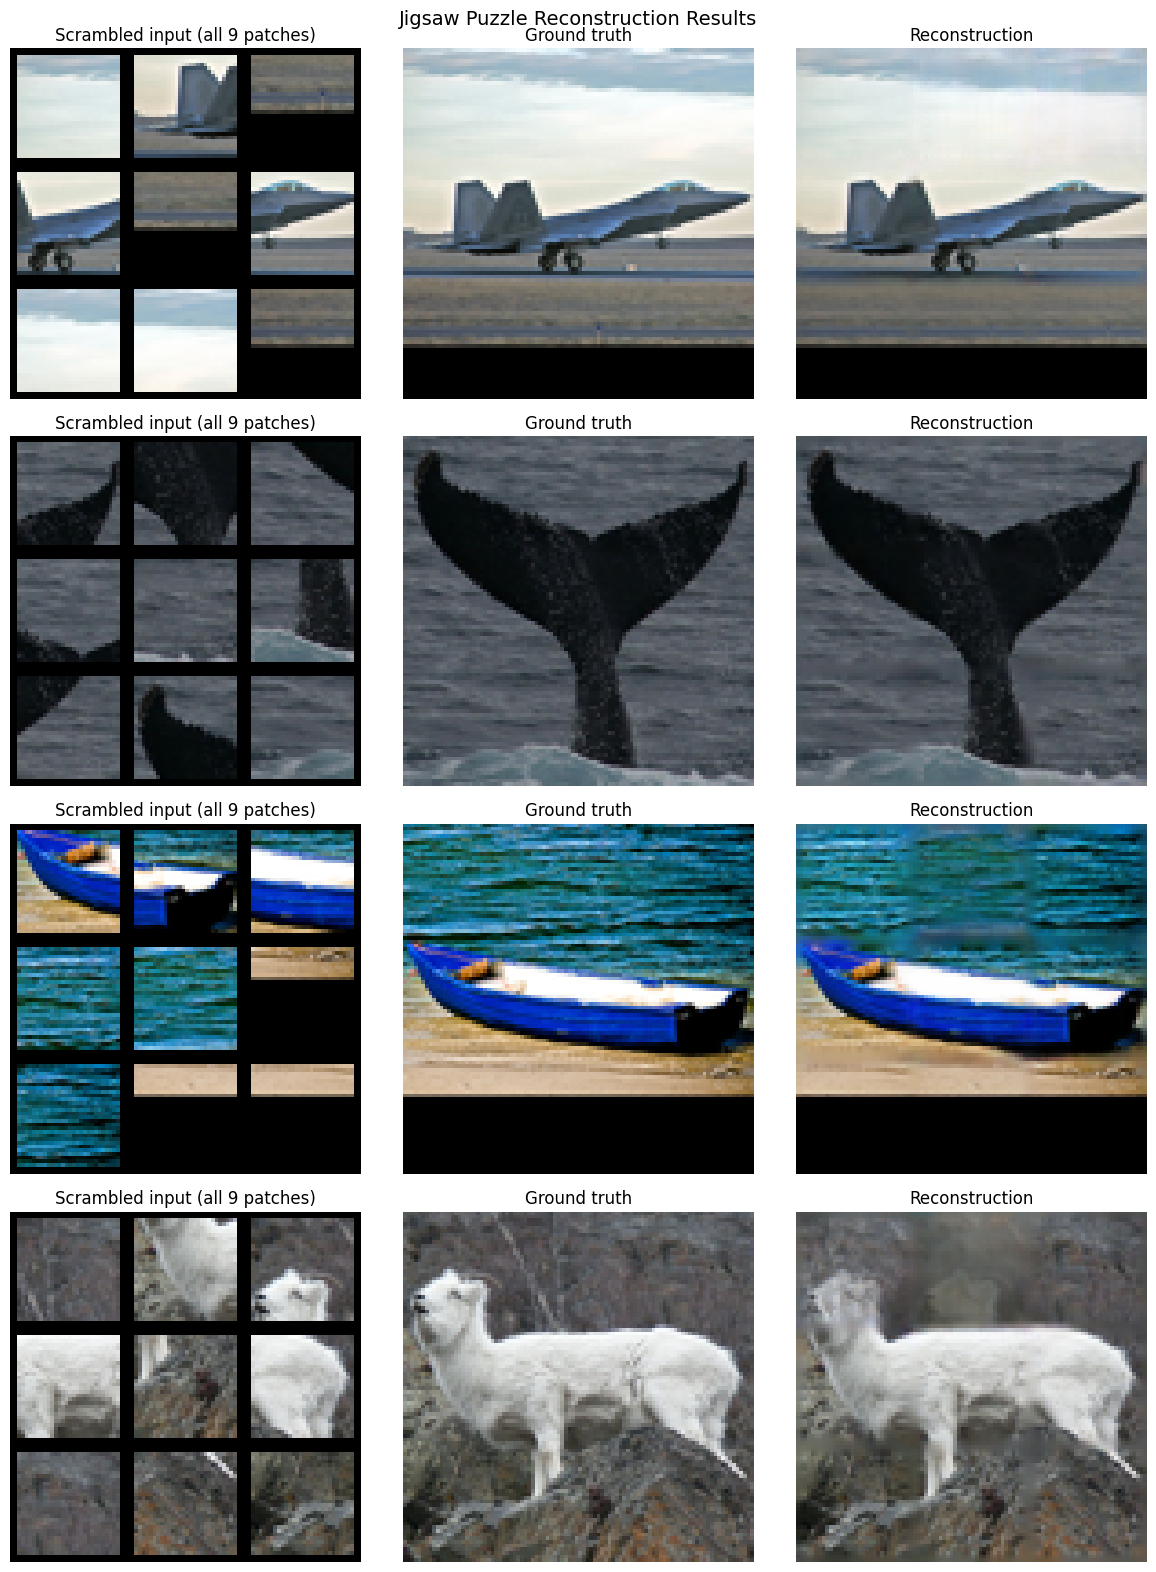

In [35]:
random_idx = np.random.randint(0, len(test_generator))
X_test, Y_test = test_generator[random_idx]
preds = model.predict(X_test[:4], verbose=0)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    # build scrambled canvas showing all 9 patches with visible gaps
    scrambled = np.zeros((96, 96, 3), dtype=np.float32)
    for p in range(9):
        r, c = p // 3, p % 3
        scrambled[r*32+2 : r*32+30, c*32+2 : c*32+30] = X_test[i, p]

    axes[i, 0].imshow(scrambled)
    axes[i, 0].set_title("Scrambled input (all 9 patches)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(np.clip(Y_test[i], 0, 1))
    axes[i, 1].set_title("Ground truth")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(np.clip(preds[i], 0, 1))
    axes[i, 2].set_title("Reconstruction")
    axes[i, 2].axis('off')

plt.suptitle("Jigsaw Puzzle Reconstruction Results", fontsize=14)
plt.tight_layout()
plt.show()

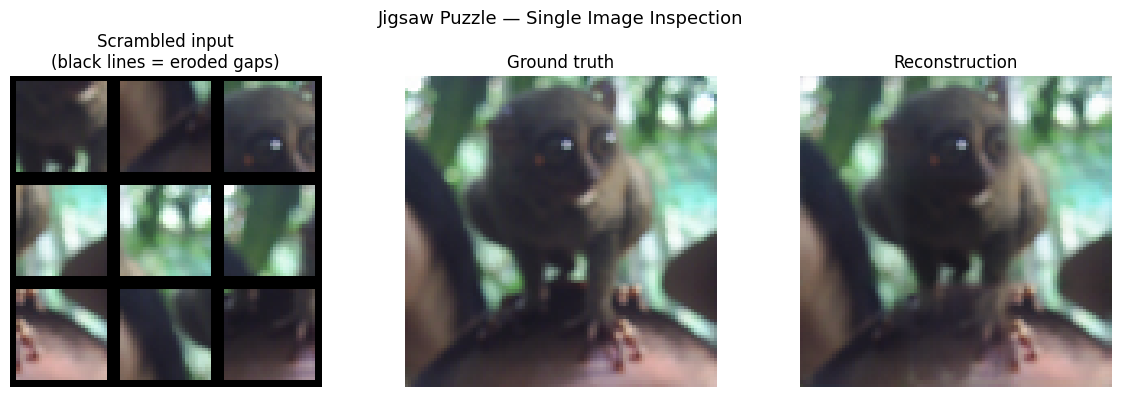

In [37]:
# single image: scrambled input vs ground truth vs reconstruction
# run repeatedly to see different random samples
random_idx = np.random.randint(0, len(test_generator))
X_test, Y_test = test_generator[random_idx]
i = np.random.randint(0, len(X_test))

# get model prediction for this one image
pred = model.predict(X_test[i:i+1], verbose=0)[0]

# build scrambled canvas — all 9 patches placed in their scrambled positions
scrambled = np.zeros((96, 96, 3), dtype=np.float32)
for p in range(9):
    r, c = p // 3, p % 3
    scrambled[r*32+2 : r*32+30, c*32+2 : c*32+30] = X_test[i, p]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(scrambled)
axes[0].set_title("Scrambled input\n(black lines = eroded gaps)")
axes[0].axis('off')

axes[1].imshow(np.clip(Y_test[i], 0, 1))
axes[1].set_title("Ground truth")
axes[1].axis('off')

axes[2].imshow(np.clip(pred, 0, 1))
axes[2].set_title("Reconstruction")
axes[2].axis('off')

plt.suptitle("Jigsaw Puzzle — Single Image Inspection", fontsize=13)
plt.tight_layout()
plt.show()

## Results

The model was evaluated on 10,000 test images over 10 rounds with different scramble seeds.

Mean MAE came out to 0.0456 with a **per-image std of 0.0460**, which reflects how much reconstruction error varies from image to image. The **per-batch std is 0.0005**, consistent with the baseline evaluation protocol above. **This is a 74.9%% improvement over the baseline MAE of 0.1822**.

The full model has 2,646,540 trainable parameters, under the 6M limit. The three stages are: a shared CNN patch encoder (residual blocks from Cifar_10_separation demo), a transformer reasoning module with positional embeddings (from ViT slides), and a decoder combining soft permutation with a U-Net refiner (from Inpainting_satellite_images demo). The model was trained for 68 epochs using MAE loss and AdamW, with EarlyStopping triggering automatically.

Pretrained weights are available via gdown (FILE_ID: 1tkutp80XP7prcfCs4nFWoHmILZ3b8PY8):

import gdown
gdown.download("https://drive.google.com/uc?id=1tkutp80XP7prcfCs4nFWoHmILZ3b8PY8",
               "jigsaw_best.weights.h5", quiet=False)
model.load_weights("jigsaw_best.weights.h5")